In [ ]:
import torch
import librosa
import numpy as np
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from scipy.spatial.distance import cosine

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")
model.to(device)
model.eval()

d:\Projects\Kaldi\Minimal_POC\.kaldi\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 1040.29it/s, Materializing param=masked_spec_embed]                                            
Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Wav2Vec2Model(
  (feature_extractor): Wav2Vec2FeatureEncoder(
    (conv_layers): ModuleList(
      (0): Wav2Vec2GroupNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (activation): GELUActivation()
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
      )
      (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
      (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): Wav2Vec2FeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Wav2Vec2Encoder(
    (pos_conv_embed): Wav2Vec2PositionalConvEmbedding(
  

In [ ]:
def extract_embedding(audio, sr=16000):
    inputs = processor(audio, sampling_rate=sr, return_tensors="pt", padding=True)
    input_values = inputs.input_values.to(device)

    with torch.no_grad():
        outputs = model(input_values)

    hidden_states = outputs.last_hidden_state  # (1, time, dim)

    # Mean pooling across time
    embedding = torch.mean(hidden_states, dim=1).squeeze().cpu().numpy()

    return embedding

In [ ]:
import os

reference_dir = "reference"
reference_embeddings = {}

for file in os.listdir(reference_dir):
    if file.endswith(".wav"):
        word = file.replace(".wav", "")
        audio, sr = librosa.load(os.path.join(reference_dir, file), sr=16000)

        emb = extract_embedding(audio)
        reference_embeddings[word] = emb

print("Loaded reference words:", list(reference_embeddings.keys()))

Loaded reference words: ['shake', 'sharp', 'sheep', 'shiny', 'shivering', 'shockingly', 'short', 'shouting', 'shy']


In [ ]:
def segment_audio(y, sr):
    hop_length = 512
    rms = librosa.feature.rms(y=y, frame_length=2048, hop_length=hop_length)[0]

    SILENCE_THRESHOLD = 0.02
    MIN_SILENCE_SEC = 0.5

    silent_frames = rms < SILENCE_THRESHOLD
    min_silence_frames = int(MIN_SILENCE_SEC * sr / hop_length)

    segments = []
    start = 0
    i = 0

    while i < len(silent_frames):
        if silent_frames[i]:
            silence_start = i
            while i < len(silent_frames) and silent_frames[i]:
                i += 1
            silence_end = i

            if silence_end - silence_start > min_silence_frames:
                end = silence_start * hop_length
                if end > start:
                    segments.append((start, end))
                start = silence_end * hop_length
        else:
            i += 1

    if start < len(y):
        segments.append((start, len(y)))

    return segments

In [ ]:
test_audio, sr = librosa.load("test/input1.wav", sr=16000)
segments = segment_audio(test_audio, sr)

print("Detected segments:", len(segments))

Detected segments: 9


In [ ]:
for idx, (s, e) in enumerate(segments):
    word_audio = test_audio[s:e]

    if len(word_audio) < 400:
        continue

    test_emb = extract_embedding(word_audio)

    similarities = {}

    for ref_word, ref_emb in reference_embeddings.items():
        sim = 1 - cosine(test_emb, ref_emb)
        similarities[ref_word] = sim

    best_match = max(similarities, key=similarities.get)

    print(f"\nSegment {idx+1}")
    print("Best match:", best_match)
    print("Similarity:", round(similarities[best_match], 3))


Segment 1
Best match: shockingly
Similarity: 0.765

Segment 2
Best match: sheep
Similarity: 0.825

Segment 3
Best match: sheep
Similarity: 0.685

Segment 4
Best match: sheep
Similarity: 0.837

Segment 5
Best match: sheep
Similarity: 0.765

Segment 6
Best match: shake
Similarity: 0.788

Segment 7
Best match: short
Similarity: 0.771

Segment 8
Best match: shockingly
Similarity: 0.732

Segment 9
Best match: sheep
Similarity: 0.811


In [ ]:
phoneme_dict = {
    "shy": ["SH", "AY"],
    "sheep": ["SH", "IY", "P"],
    "shake": ["SH", "EY", "K"],
    "short": ["SH", "AO", "R", "T"],
    "sharp": ["SH", "AA", "R", "P"],
    "shiny": ["SH", "AY", "N", "IY"],
    "shouting": ["SH", "AW", "T", "IH", "NG"],
    "shivering": ["SH", "IH", "V", "ER", "IH", "NG"],
    "shockingly": ["SH", "AA", "K", "IH", "NG", "L", "IY"]
}

In [ ]:
def extract_frame_embeddings(audio, sr=16000):
    inputs = processor(audio, sampling_rate=sr, return_tensors="pt", padding=True)
    input_values = inputs.input_values.to(device)

    with torch.no_grad():
        outputs = model(input_values)

    return outputs.last_hidden_state.squeeze(0).cpu().numpy()  # (time, dim)

In [ ]:
def slice_phoneme_windows(frame_embs, phonemes):
    n_frames = len(frame_embs)
    n_ph = len(phonemes)

    window_size = n_frames // n_ph
    phoneme_windows = {}

    for i, ph in enumerate(phonemes):
        start = i * window_size
        end = (i + 1) * window_size if i < n_ph - 1 else n_frames

        phoneme_windows[ph] = frame_embs[start:end]

    return phoneme_windows

In [ ]:
phoneme_prototypes = {}

for word, phonemes in phoneme_dict.items():
    ref_audio, _ = librosa.load(f"reference/{word}.wav", sr=16000)
    frame_embs = extract_frame_embeddings(ref_audio)

    windows = slice_phoneme_windows(frame_embs, phonemes)

    for ph, emb_window in windows.items():
        proto = np.mean(emb_window, axis=0)

        if ph not in phoneme_prototypes:
            phoneme_prototypes[ph] = []

        phoneme_prototypes[ph].append(proto)

# Average prototypes
for ph in phoneme_prototypes:
    phoneme_prototypes[ph] = np.mean(phoneme_prototypes[ph], axis=0)

In [ ]:
def analyze_word(word_audio, expected_phonemes):
    frame_embs = extract_frame_embeddings(word_audio)
    windows = slice_phoneme_windows(frame_embs, expected_phonemes)

    scores = {}

    for ph, emb_window in windows.items():
        test_vec = np.mean(emb_window, axis=0)

        ref_vec = phoneme_prototypes.get(ph)

        if ref_vec is None:
            continue

        similarity = 1 - cosine(test_vec, ref_vec)

        scores[ph] = similarity

    return scores

In [ ]:
def classify_phoneme_errors(scores, threshold=0.7):
    results = {}

    for ph, sim in scores.items():
        if sim >= threshold:
            results[ph] = "OK"
        elif sim >= 0.5:
            results[ph] = "Weak"
        else:
            results[ph] = "Likely Error"

    return results

In [ ]:
import matplotlib.pyplot as plt

def plot_heatmap(scores, word_label):
    phonemes = list(scores.keys())
    values = [scores[p] for p in phonemes]

    plt.figure()
    plt.imshow([values], aspect="auto", cmap="RdYlGn")
    #plt.imshow([values], aspect="auto", cmap="coolwarm")
    plt.yticks([])
    plt.xticks(range(len(phonemes)), phonemes)
    plt.colorbar(label="Similarity")
    plt.title(f"Phoneme Similarity – {word_label}")
    plt.show()

{'SH': np.float32(0.7776653), 'AA': np.float32(0.7472252), 'K': np.float32(0.63647294), 'IH': np.float32(0.7562395), 'NG': np.float32(0.72151506), 'L': np.float32(0.613393), 'IY': np.float32(0.48587424)}
{'SH': 'OK', 'AA': 'OK', 'K': 'Weak', 'IH': 'OK', 'NG': 'OK', 'L': 'Weak', 'IY': 'Likely Error'}


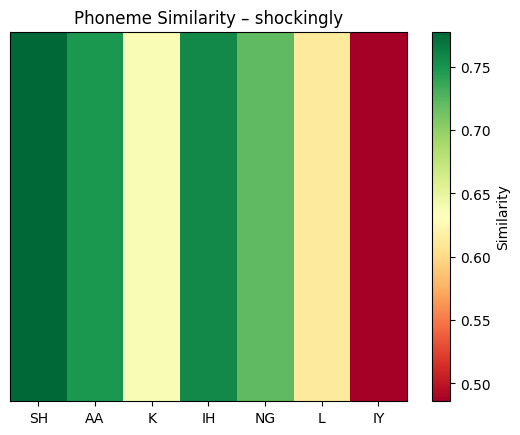

In [ ]:
test_word = "shockingly"
scores = analyze_word(word_audio, phoneme_dict[test_word])
errors = classify_phoneme_errors(scores)

print(scores)
print(errors)

plot_heatmap(scores, test_word)